# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.2

NGSOLVE = True

lc = 0.6

from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
# mesh = CleanCircle(R=R, verbosity=0, lc=lc)


In [2]:
mesh.n_triangles

99

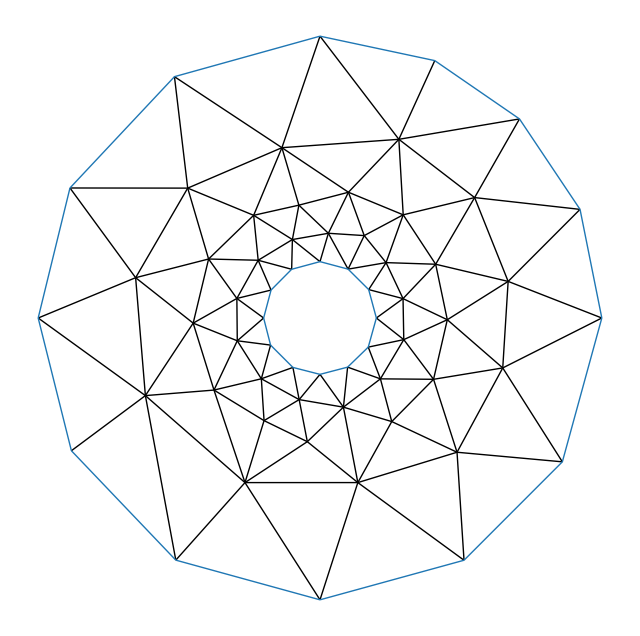

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
mesh.curve_region(Regions.d_Omega, radius=r)


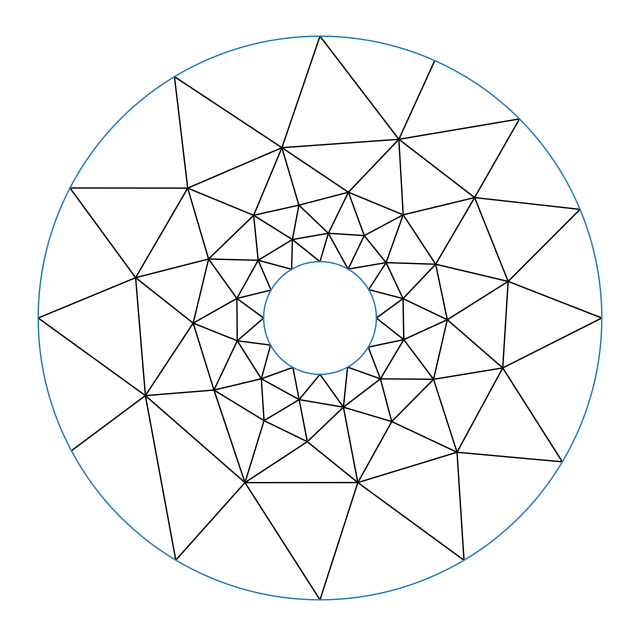

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
# from trefftz.dg.assemblers import SerialNumerics
# NtD_modes = 15
# a = 0.5
# b = 0.5
# d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

In [12]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [13]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 16.0
Ntheta = 3
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [14]:
basis.N_DOF

297

In [15]:
# from trefftz.dg.assemblers import SerialAssembler

# assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [16]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [17]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [18]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 13/13 [00:00<00:00, 109.93edge/s]


region: d_Omega


Interior: 100%|██████████| 136/136 [00:00<00:00, 2050.31edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 13/13 [01:02<00:00,  4.78s/edge]


np.concatenate(values).shape=(4901796,),
 (6642,),
 (6642,)


ValueError: all index and data arrays must have the same length

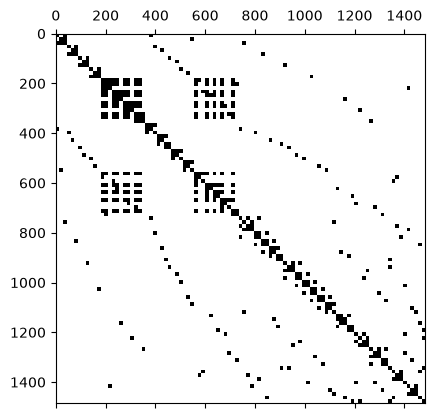

In [102]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [103]:
b = P.assemble_RHS()

region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.7778967158918725+0.19492912628103193j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.2606926944832597-0.28696332385524065j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.1225644065963421-0.07963559572287476j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.38081292531079325-0.19917466804308936j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.4816689122107608-0.4821178296005607j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.5594111590817432-0.42781888066272283j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.4292939705781381-0.009132694925952742j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(0.059321602726984834-0.07048277271024028j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-0.4553571016080005-0.5880340918736722j)
region=<Regions.d_Omega: 'd_Omega'>, value=np.complex128(-1.3080960557134405+0.5216667969018781j)
region=<Re

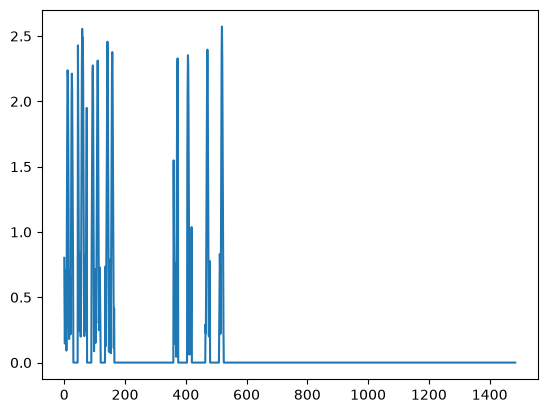

In [104]:
import numpy as np 
plt.plot(np.abs(b))

In [105]:
P.solve()

In [106]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-3.16435045e+01-1.57766860e+01j,  9.22254164e+00-2.23033890e+00j,
        -3.63451209e+01-3.70305358e+01j, ...,
        -1.17090840e+02-1.17316556e+02j,  4.47562152e+01+1.13548486e+02j,
         4.65751391e+01-6.25148259e+01j],
       [-7.23547608e+00-1.48075699e+02j, -1.19744076e+02+5.30285716e+01j,
         1.10029182e+02+3.26133753e+01j, ...,
        -1.23027314e+02-1.78965961e+02j, -7.15332336e+01+1.76407580e+02j,
         1.65389279e+02+2.10960166e+01j],
       [-3.86588951e+00-9.39776584e+00j, -9.46174193e+00-1.39858982e+00j,
        -3.47165523e+00+8.76385203e+00j, ...,
        -1.44770363e+01+1.10014461e+01j,  1.30440578e+01+6.36042759e+00j,
         6.97666667e+00-9.34040694e+00j],
       ...,
       [ 1.13200037e-01+7.95686351e-02j,  2.25640970e-02+3.24247533e-01j,
         4.49140375e-01+3.89786145e-01j, ...,
         8.75524247e-01+4.99016340e-01j,  6.55219601e-01-1.10704294e-01j,
         4.13565656e-01-3.88136184e-02j],
       [ 4.71048613e+00+2.43507844e+00j,  2.

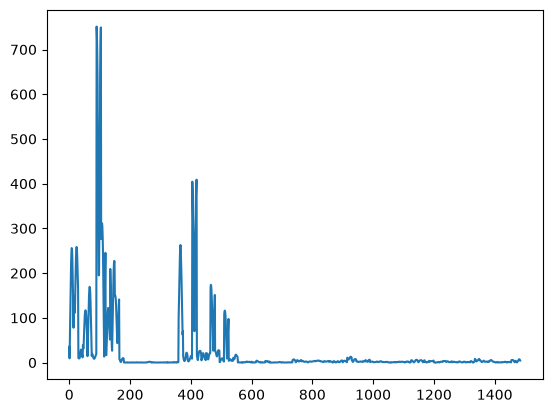

In [107]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [108]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [109]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

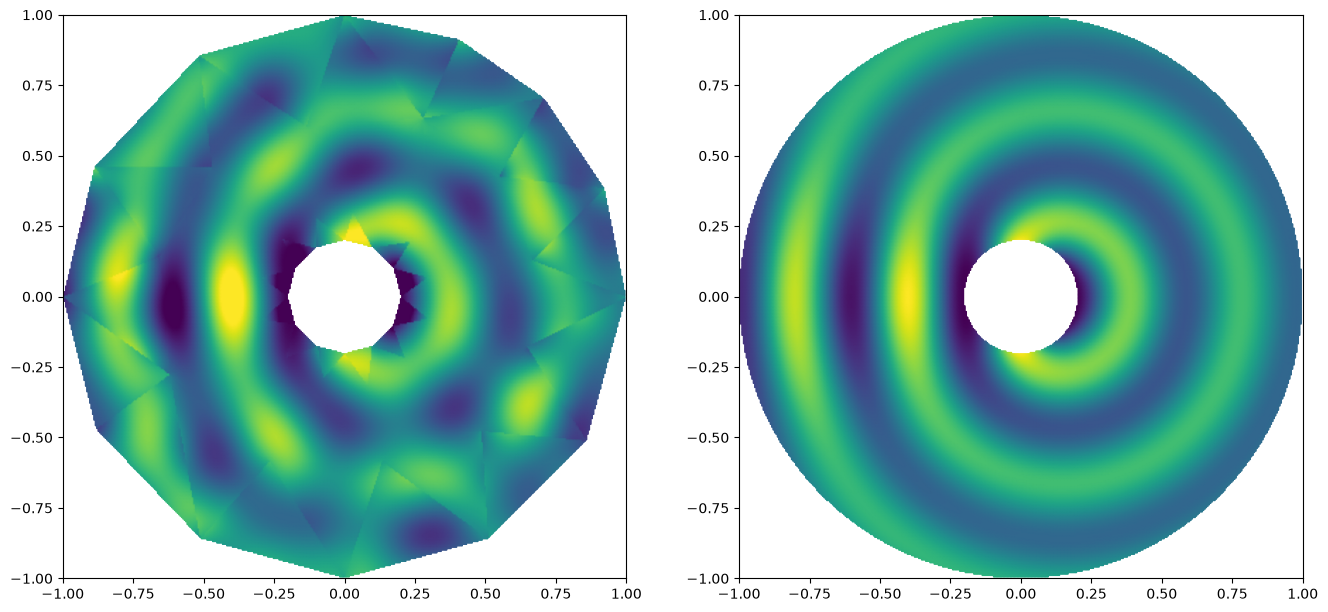

In [110]:
import numpy as np
N = 400
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

RHO = np.sqrt(X**2 + Y**2)
THETA = np.arctan2(Y,X)
from scipy.special import jn, hankel1

Z_exact = sum( 1j**n*jn(n, k*r)*hankel1(n, k*RHO)/hankel1(n, k*r)*np.exp(1j*n*(THETA-np.pi)) for n in range(-50,51))
Z_exact[RHO < r ] = np.nan
Z_exact[RHO > R ] = np.nan

import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), vmin=-1, vmax=1, shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')

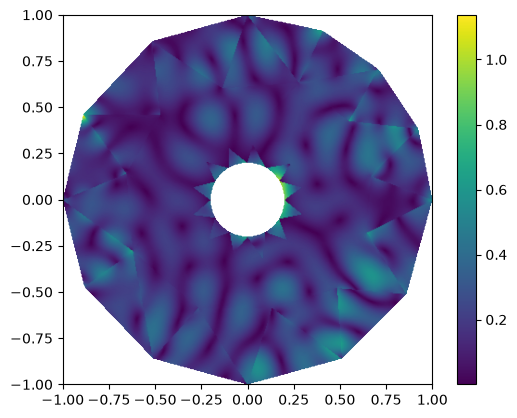

In [111]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()